# 01 Baseline PM2.5 Model V3 - High Coverage Hexagons Only

Following V1 approach: use only hexagons with continuous data for reliable predictions.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from datetime import datetime
from tqdm import tqdm
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print(f"Starting analysis: {datetime.now()}")

Starting analysis: 2025-09-01 03:02:07.571576


## 1. Load and Analyze Coverage

In [2]:
DATA_PATH = '/Users/vojtech/Code/Bard89/smoglens-data/pm25_enriched_2023_2025_v4_20250830_222050.csv'

print("Loading dataset...")
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df = df.sort_values(['hex7_id', 'timestamp']).reset_index(drop=True)

print(f"Full dataset: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Total hexagons: {df['hex7_id'].nunique()}")

Loading dataset...
Full dataset: (9457112, 39)
Date range: 2023-07-14 16:00:00+00:00 to 2025-07-26 05:00:00+00:00
Total hexagons: 634


In [3]:
coverage_stats = df.groupby('hex7_id').agg({
    'pm25_ugm3_mean': [
        'count',
        lambda x: x.notna().sum(),
        lambda x: x.notna().mean()
    ],
    'timestamp': ['min', 'max']
}).round(3)

coverage_stats.columns = ['total_hours', 'valid_pm25', 'coverage_ratio', 'start_date', 'end_date']
coverage_stats['duration_days'] = (coverage_stats['end_date'] - coverage_stats['start_date']).dt.days

print("\nCoverage Distribution:")
print(coverage_stats['coverage_ratio'].describe())

print(f"\nHexagons by coverage threshold:")
for threshold in [0.7, 0.8, 0.85, 0.9, 0.95]:
    count = (coverage_stats['coverage_ratio'] >= threshold).sum()
    print(f"  >= {threshold:.0%}: {count} hexagons")


Coverage Distribution:
count   634.000
mean      0.800
std       0.356
min       0.000
25%       0.911
50%       0.968
75%       0.985
max       1.000
Name: coverage_ratio, dtype: float64

Hexagons by coverage threshold:
  >= 70%: 520 hexagons
  >= 80%: 510 hexagons
  >= 85%: 500 hexagons
  >= 90%: 485 hexagons
  >= 95%: 412 hexagons


## 2. Select High Coverage Hexagons

In [4]:
COVERAGE_THRESHOLD = 0.90
MIN_DURATION_DAYS = 100

high_coverage_hexagons = coverage_stats[
    (coverage_stats['coverage_ratio'] >= COVERAGE_THRESHOLD) & 
    (coverage_stats['duration_days'] >= MIN_DURATION_DAYS)
].index.tolist()

print(f"Selected {len(high_coverage_hexagons)} hexagons with >= {COVERAGE_THRESHOLD:.0%} coverage")
print(f"and >= {MIN_DURATION_DAYS} days of data")

df_filtered = df[df['hex7_id'].isin(high_coverage_hexagons)].copy()
print(f"\nFiltered dataset: {df_filtered.shape}")
print(f"PM2.5 coverage in filtered data: {df_filtered['pm25_ugm3_mean'].notna().mean():.1%}")

Selected 485 hexagons with >= 90% coverage
and >= 100 days of data

Filtered dataset: (7320911, 39)
PM2.5 coverage in filtered data: 97.1%


## 3. Handle Missing Data and Outliers

In [5]:
pm25_cap = df_filtered['pm25_ugm3_mean'].quantile(0.999)
print(f"Capping PM2.5 at 99.9th percentile: {pm25_cap:.1f} μg/m³")
df_filtered['pm25_ugm3_mean'] = df_filtered['pm25_ugm3_mean'].clip(upper=pm25_cap)

df_filtered['pm25'] = df_filtered.groupby('hex7_id')['pm25_ugm3_mean'].transform(
    lambda x: x.interpolate(method='linear', limit=3)
)

print(f"PM2.5 missing after interpolation: {df_filtered['pm25'].isna().mean():.2%}")

df_filtered = df_filtered.dropna(subset=['pm25'])
print(f"Final dataset after removing remaining NaN: {df_filtered.shape}")

Capping PM2.5 at 99.9th percentile: 53.0 μg/m³
PM2.5 missing after interpolation: 1.09%
Final dataset after removing remaining NaN: (7241466, 40)


## 4. Create Time Series Features

In [6]:
df_filtered = df_filtered.sort_values(['hex7_id', 'timestamp']).reset_index(drop=True)

lag_hours = [1, 2, 3, 4, 5, 6, 12, 24]
print("Creating lag features...")
for lag in tqdm(lag_hours):
    df_filtered[f'lag_{lag}h'] = df_filtered.groupby('hex7_id')['pm25'].shift(lag)

print("Creating rolling statistics...")
df_filtered['rolling_mean_6h'] = df_filtered.groupby('hex7_id')['pm25'].transform(
    lambda x: x.rolling(6, min_periods=3).mean()
)
df_filtered['rolling_std_6h'] = df_filtered.groupby('hex7_id')['pm25'].transform(
    lambda x: x.rolling(6, min_periods=3).std()
)
df_filtered['rolling_mean_24h'] = df_filtered.groupby('hex7_id')['pm25'].transform(
    lambda x: x.rolling(24, min_periods=12).mean()
)

df_filtered['hour'] = df_filtered['timestamp'].dt.hour
df_filtered['day_of_week'] = df_filtered['timestamp'].dt.dayofweek

df_filtered['hour_sin'] = np.sin(2 * np.pi * df_filtered['hour'] / 24)
df_filtered['hour_cos'] = np.cos(2 * np.pi * df_filtered['hour'] / 24)
df_filtered['dow_sin'] = np.sin(2 * np.pi * df_filtered['day_of_week'] / 7)
df_filtered['dow_cos'] = np.cos(2 * np.pi * df_filtered['day_of_week'] / 7)

print("Features created")

Creating lag features...


100%|██████████| 8/8 [00:01<00:00,  5.85it/s]


Creating rolling statistics...
Features created


## 5. Encode Hexagons

In [7]:
le_hex = LabelEncoder()
df_filtered['hex_encoded'] = le_hex.fit_transform(df_filtered['hex7_id'])

print(f"Encoded {len(le_hex.classes_)} hexagons")
print(f"Sample: {df_filtered['hex7_id'].iloc[0]} -> {df_filtered['hex_encoded'].iloc[0]}")

Encoded 485 hexagons
Sample: 872e0122effffff -> 0


## 6. Create Targets and Features

In [8]:
horizons = [1, 2, 3, 4, 5, 6, 12, 24]
target_cols = []

for h in horizons:
    col_name = f'target_{h}h'
    df_filtered[col_name] = df_filtered.groupby('hex7_id')['pm25'].shift(-h)
    target_cols.append(col_name)

feature_cols = [
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_4h', 'lag_5h', 'lag_6h', 'lag_12h', 'lag_24h',
    'rolling_mean_6h', 'rolling_std_6h', 'rolling_mean_24h',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'hex_encoded'
]

weather_features = ['temperature_c_mean', 'humidity_pct_mean', 'pressure_hpa_mean']
for feat in weather_features:
    if feat in df_filtered.columns:
        df_filtered[feat] = df_filtered[feat].fillna(df_filtered[feat].median())
        feature_cols.append(feat)

print(f"Features: {len(feature_cols)}")
print(feature_cols)

Features: 19
['lag_1h', 'lag_2h', 'lag_3h', 'lag_4h', 'lag_5h', 'lag_6h', 'lag_12h', 'lag_24h', 'rolling_mean_6h', 'rolling_std_6h', 'rolling_mean_24h', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'hex_encoded', 'temperature_c_mean', 'humidity_pct_mean', 'pressure_hpa_mean']


## 7. Train/Test Split

In [9]:
df_filtered = df_filtered.dropna(subset=feature_cols + target_cols)

df_filtered['year'] = df_filtered['timestamp'].dt.year

train_data = df_filtered[df_filtered['year'].isin([2023, 2024])].copy()
test_data = df_filtered[df_filtered['year'] == 2025].copy()

print(f"Train: {len(train_data):,} samples ({train_data['timestamp'].min()} to {train_data['timestamp'].max()})")
print(f"Test: {len(test_data):,} samples ({test_data['timestamp'].min()} to {test_data['timestamp'].max()})")
print(f"Train hexagons: {train_data['hex7_id'].nunique()}")
print(f"Test hexagons: {test_data['hex7_id'].nunique()}")

Train: 5,149,984 samples (2023-07-28 10:00:00+00:00 to 2024-12-31 23:00:00+00:00)
Test: 2,068,202 samples (2025-01-01 00:00:00+00:00 to 2025-07-25 03:00:00+00:00)
Train hexagons: 485
Test hexagons: 479


In [10]:
X_train = train_data[feature_cols]
X_test = test_data[feature_cols]

y_train = {}
y_test = {}

for col in target_cols:
    y_train[col] = train_data[col]
    y_test[col] = test_data[col]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print("\nFeature means:")
print(X_train[['lag_1h', 'lag_6h', 'lag_24h']].mean())

X_train shape: (5149984, 19)
X_test shape: (2068202, 19)

Feature means:
lag_1h    8.324
lag_6h    8.327
lag_24h   8.333
dtype: float64


## 8. Train All Models

In [11]:
results = {}
predictions = {}

numeric_features = [f for f in feature_cols if f != 'hex_encoded']
X_train_numeric = X_train[numeric_features]
X_test_numeric = X_test[numeric_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

for target_col in target_cols:
    horizon = target_col.split('_')[1]
    print(f"\nTraining for {horizon} prediction...")
    
    y_tr = y_train[target_col]
    y_te = y_test[target_col]
    
    results[horizon] = {}
    predictions[horizon] = {}
    
    lag_col = f'lag_{horizon[:-1]}h' if f'lag_{horizon[:-1]}h' in X_test.columns else 'lag_1h'
    persistence_pred = X_test[lag_col].values
    persistence_mae = mean_absolute_error(y_te, persistence_pred)
    persistence_rmse = np.sqrt(mean_squared_error(y_te, persistence_pred))
    persistence_r2 = r2_score(y_te, persistence_pred)
    
    results[horizon]['Persistence'] = {
        'mae': persistence_mae, 
        'rmse': persistence_rmse,
        'r2': persistence_r2
    }
    predictions[horizon]['Persistence'] = persistence_pred
    
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_tr)
    lr_pred = lr.predict(X_test_scaled)
    lr_mae = mean_absolute_error(y_te, lr_pred)
    lr_rmse = np.sqrt(mean_squared_error(y_te, lr_pred))
    lr_r2 = r2_score(y_te, lr_pred)
    
    results[horizon]['LinearReg'] = {
        'mae': lr_mae,
        'rmse': lr_rmse,
        'r2': lr_r2,
        'model': lr
    }
    predictions[horizon]['LinearReg'] = lr_pred
    
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_tr)
    ridge_pred = ridge.predict(X_test_scaled)
    ridge_mae = mean_absolute_error(y_te, ridge_pred)
    ridge_rmse = np.sqrt(mean_squared_error(y_te, ridge_pred))
    ridge_r2 = r2_score(y_te, ridge_pred)
    
    results[horizon]['Ridge'] = {
        'mae': ridge_mae,
        'rmse': ridge_rmse,
        'r2': ridge_r2,
        'model': ridge
    }
    predictions[horizon]['Ridge'] = ridge_pred
    
    lgb_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'n_jobs': 8,
        'random_state': 42
    }
    
    train_set = lgb.Dataset(
        X_train,
        label=y_tr,
        categorical_feature=['hex_encoded']
    )
    valid_set = lgb.Dataset(
        X_test,
        label=y_te,
        reference=train_set,
        categorical_feature=['hex_encoded']
    )
    
    lgb_model = lgb.train(
        lgb_params,
        train_set,
        num_boost_round=500,
        valid_sets=[valid_set],
        callbacks=[
            lgb.early_stopping(stopping_rounds=20),
            lgb.log_evaluation(period=0)
        ]
    )
    
    lgb_pred = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)
    lgb_mae = mean_absolute_error(y_te, lgb_pred)
    lgb_rmse = np.sqrt(mean_squared_error(y_te, lgb_pred))
    lgb_r2 = r2_score(y_te, lgb_pred)
    
    results[horizon]['LightGBM'] = {
        'mae': lgb_mae,
        'rmse': lgb_rmse,
        'r2': lgb_r2,
        'model': lgb_model
    }
    predictions[horizon]['LightGBM'] = lgb_pred
    
    print(f"  Persistence: MAE={persistence_mae:.2f}, R²={persistence_r2:.3f}")
    print(f"  LinearReg:  MAE={lr_mae:.2f}, R²={lr_r2:.3f}")
    print(f"  Ridge:      MAE={ridge_mae:.2f}, R²={ridge_r2:.3f}")
    print(f"  LightGBM:   MAE={lgb_mae:.2f}, R²={lgb_r2:.3f}")


Training for 1h prediction...
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[498]	valid_0's rmse: 3.15154
  Persistence: MAE=2.63, R²=0.739
  LinearReg:  MAE=2.08, R²=0.845
  Ridge:      MAE=2.08, R²=0.845
  LightGBM:   MAE=2.16, R²=0.829

Training for 2h prediction...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[436]	valid_0's rmse: 3.88949
  Persistence: MAE=3.35, R²=0.583
  LinearReg:  MAE=2.55, R²=0.765
  Ridge:      MAE=2.55, R²=0.765
  LightGBM:   MAE=2.64, R²=0.740

Training for 3h prediction...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[342]	valid_0's rmse: 4.40163
  Persistence: MAE=3.87, R²=0.456
  LinearReg:  MAE=2.90, R²=0.697
  Ridge:      MAE=2.90, R²=0.697
  LightGBM:   MAE=2.99, R²=0.667

Training for 4h prediction...
Training until validation scores don't improve for 20 rounds
Early stopping, best iter

## 9. Performance Summary Tables

In [12]:
models = ['Persistence', 'LinearReg', 'Ridge', 'LightGBM']
horizon_list = ['1h', '2h', '3h', '4h', '5h', '6h', '12h', '24h']

mae_table = pd.DataFrame(index=models, columns=horizon_list)
rmse_table = pd.DataFrame(index=models, columns=horizon_list)
r2_table = pd.DataFrame(index=models, columns=horizon_list)

for horizon in horizon_list:
    for model in models:
        mae_table.loc[model, horizon] = results[horizon][model]['mae']
        rmse_table.loc[model, horizon] = results[horizon][model]['rmse']
        r2_table.loc[model, horizon] = results[horizon][model]['r2']

print("\n" + "="*70)
print("MAE by Model and Horizon (μg/m³):")
print("="*70)
print(mae_table.round(2))

print("\n" + "="*70)
print("RMSE by Model and Horizon (μg/m³):")
print("="*70)
print(rmse_table.round(2))

print("\n" + "="*70)
print("R² by Model and Horizon:")
print("="*70)
print(r2_table.round(3))


MAE by Model and Horizon (μg/m³):
               1h    2h    3h    4h    5h    6h   12h   24h
Persistence 2.627 3.354 3.868 4.252 4.542 4.766 5.537 6.614
LinearReg   2.081 2.550 2.903 3.169 3.391 3.570 4.237 4.839
Ridge       2.081 2.550 2.903 3.169 3.391 3.570 4.237 4.839
LightGBM    2.164 2.640 2.993 3.266 3.499 3.671 4.334 4.887

RMSE by Model and Horizon (μg/m³):
               1h    2h    3h    4h    5h    6h   12h   24h
Persistence 3.893 4.925 5.623 6.134 6.519 6.811 7.842 9.281
LinearReg   3.002 3.695 4.196 4.566 4.870 5.113 6.007 6.818
Ridge       3.002 3.695 4.196 4.566 4.870 5.113 6.007 6.818
LightGBM    3.152 3.889 4.402 4.781 5.105 5.356 6.299 7.041

R² by Model and Horizon:
               1h    2h    3h    4h    5h    6h    12h    24h
Persistence 0.739 0.583 0.456 0.353 0.269 0.202 -0.058 -0.481
LinearReg   0.845 0.765 0.697 0.641 0.592 0.550  0.379  0.201
Ridge       0.845 0.765 0.697 0.641 0.592 0.550  0.379  0.201
LightGBM    0.829 0.740 0.667 0.607 0.552 0.506  0.317 

## 10. Prediction vs True Visualizations (All Models & Horizons)

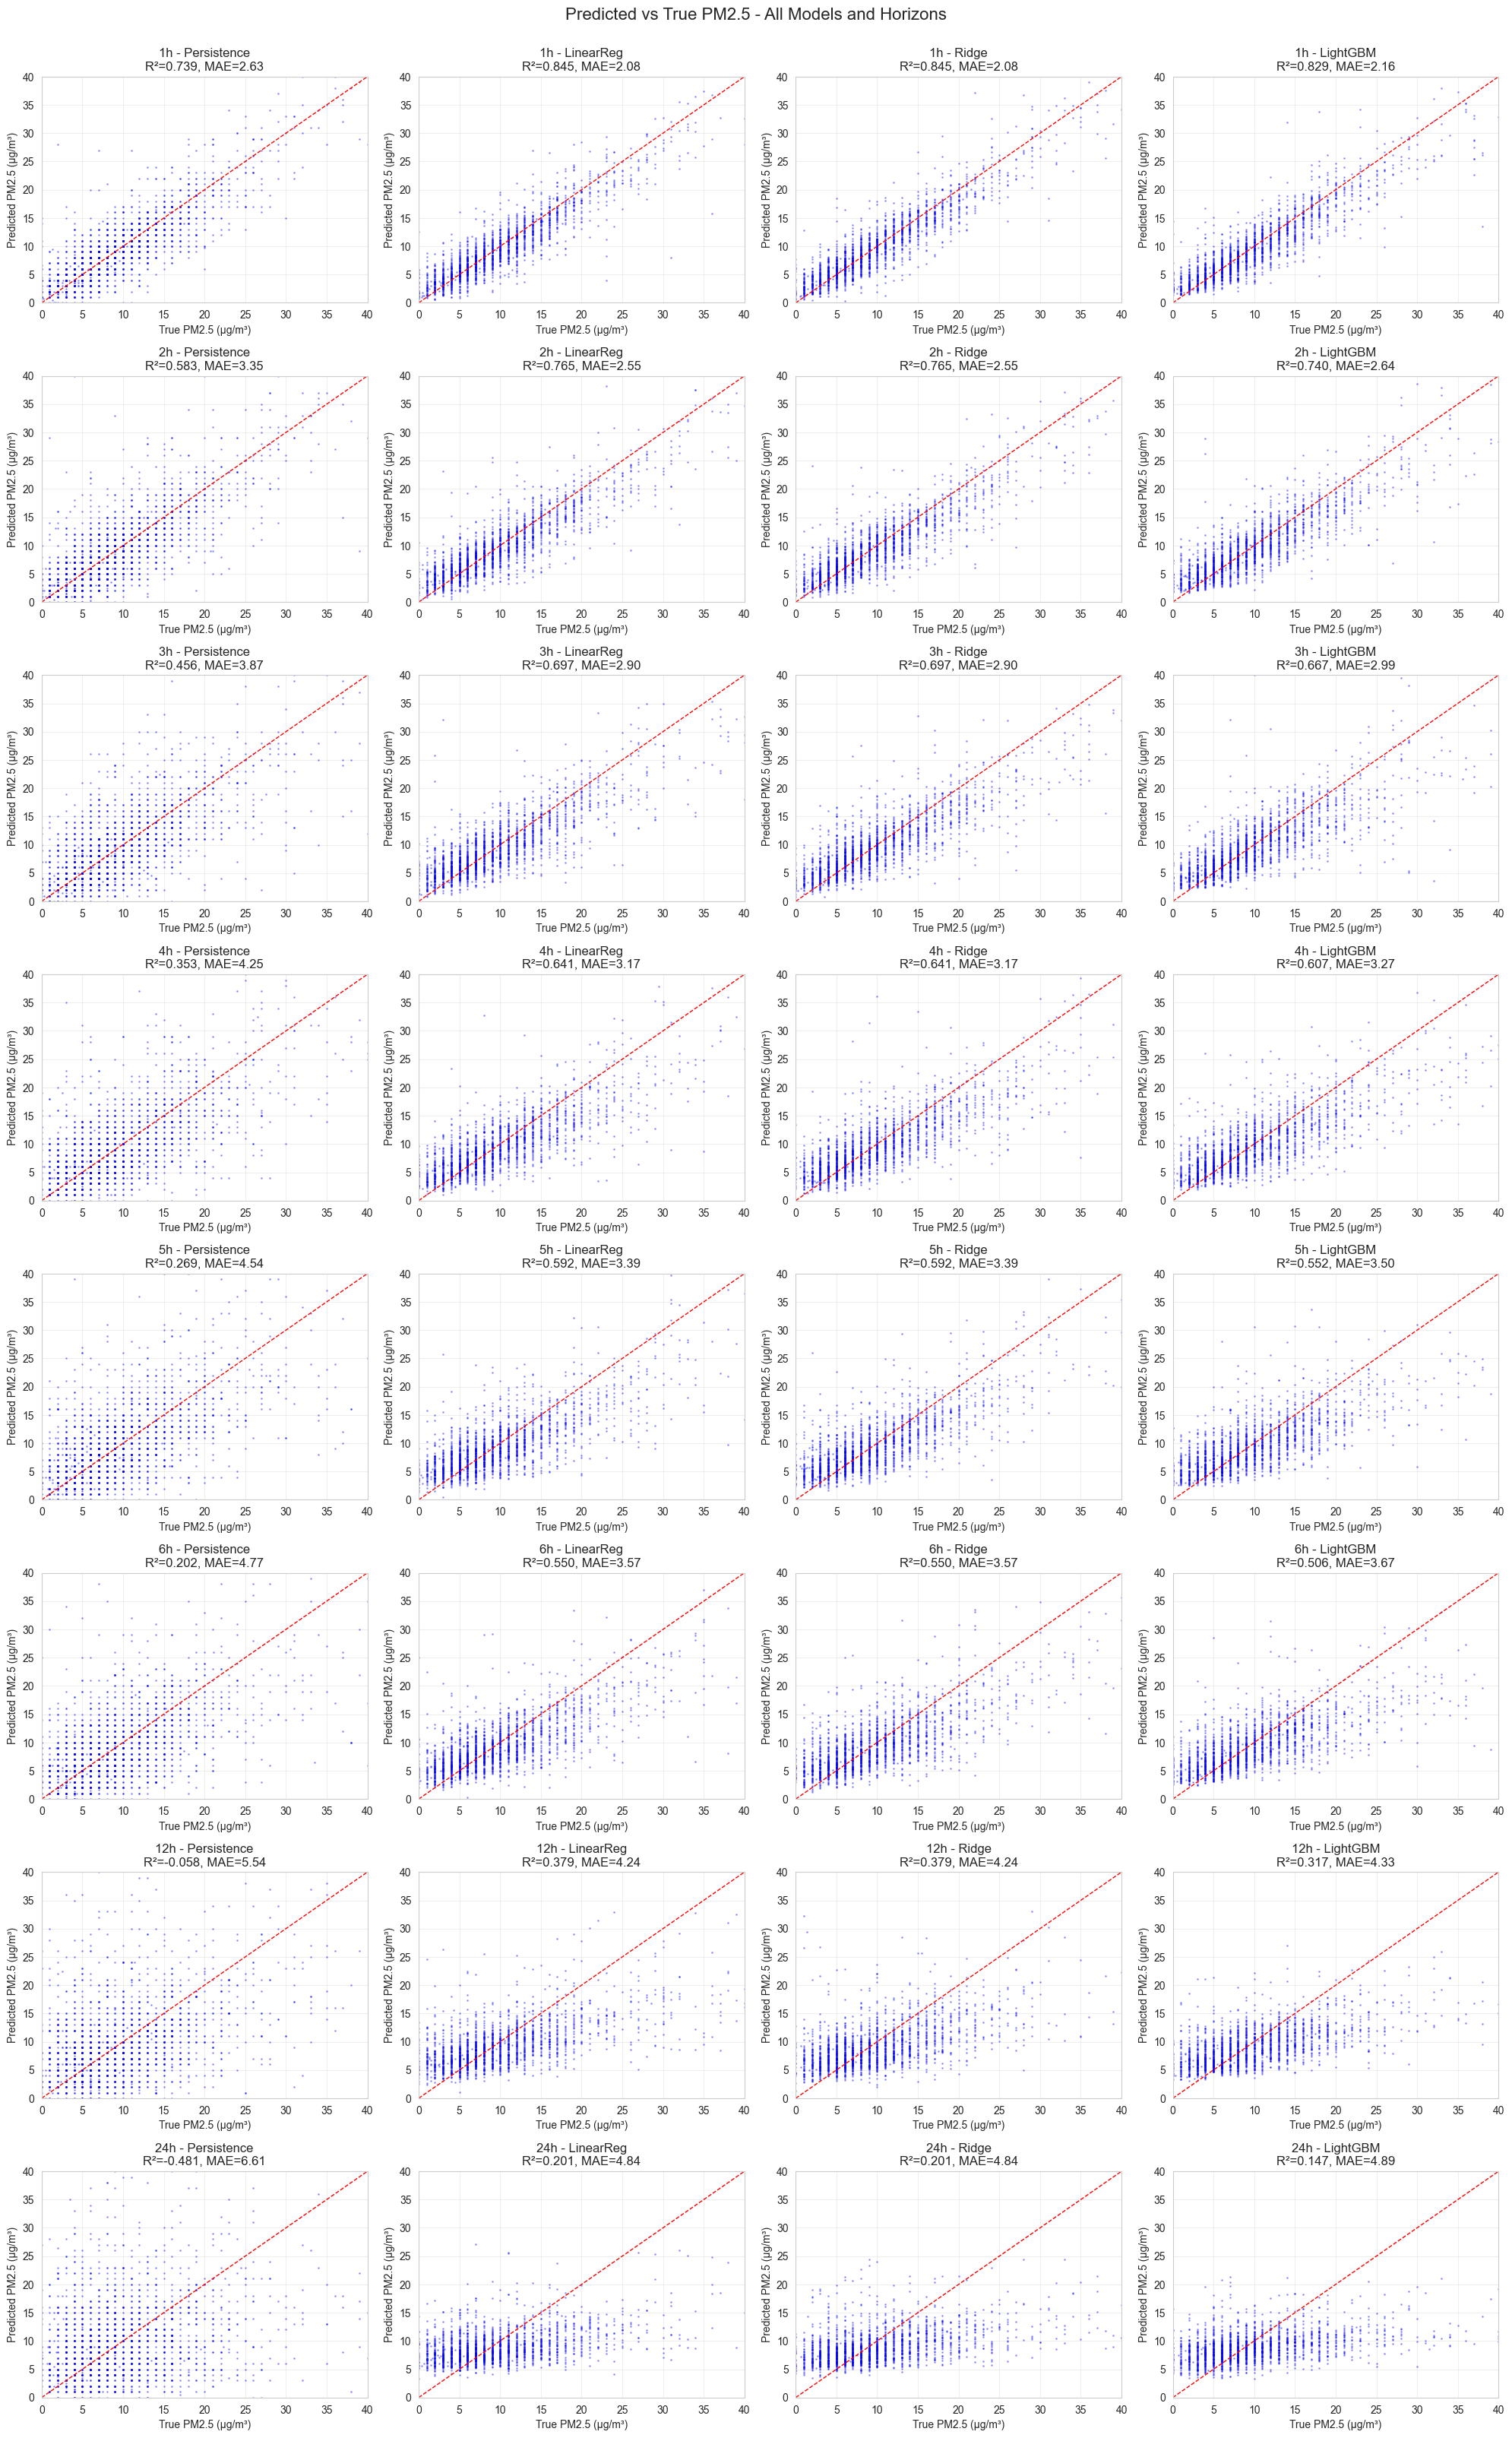

In [13]:
fig, axes = plt.subplots(8, 4, figsize=(20, 32))

for i, horizon in enumerate(horizon_list):
    y_true = y_test[f'target_{horizon}']
    
    for j, model in enumerate(models):
        ax = axes[i, j]
        y_pred = predictions[horizon][model]
        
        sample_size = min(2000, len(y_true))
        sample_idx = np.random.choice(len(y_true), sample_size, replace=False)
        
        ax.scatter(y_true.iloc[sample_idx], y_pred[sample_idx], 
                  alpha=0.3, s=1, color='blue')
        
        max_val = min(50, max(y_true.max(), np.max(y_pred)))
        ax.plot([0, max_val], [0, max_val], 'r--', lw=1)
        
        r2 = r2_table.loc[model, horizon]
        mae = mae_table.loc[model, horizon]
        
        ax.set_title(f'{horizon} - {model}\nR²={r2:.3f}, MAE={mae:.2f}')
        ax.set_xlabel('True PM2.5 (μg/m³)')
        ax.set_ylabel('Predicted PM2.5 (μg/m³)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 40)
        ax.set_ylim(0, 40)

plt.suptitle('Predicted vs True PM2.5 - All Models and Horizons', fontsize=16, y=1.001)
plt.tight_layout()
plt.show()

## 11. Feature Importance (LightGBM - All Horizons)

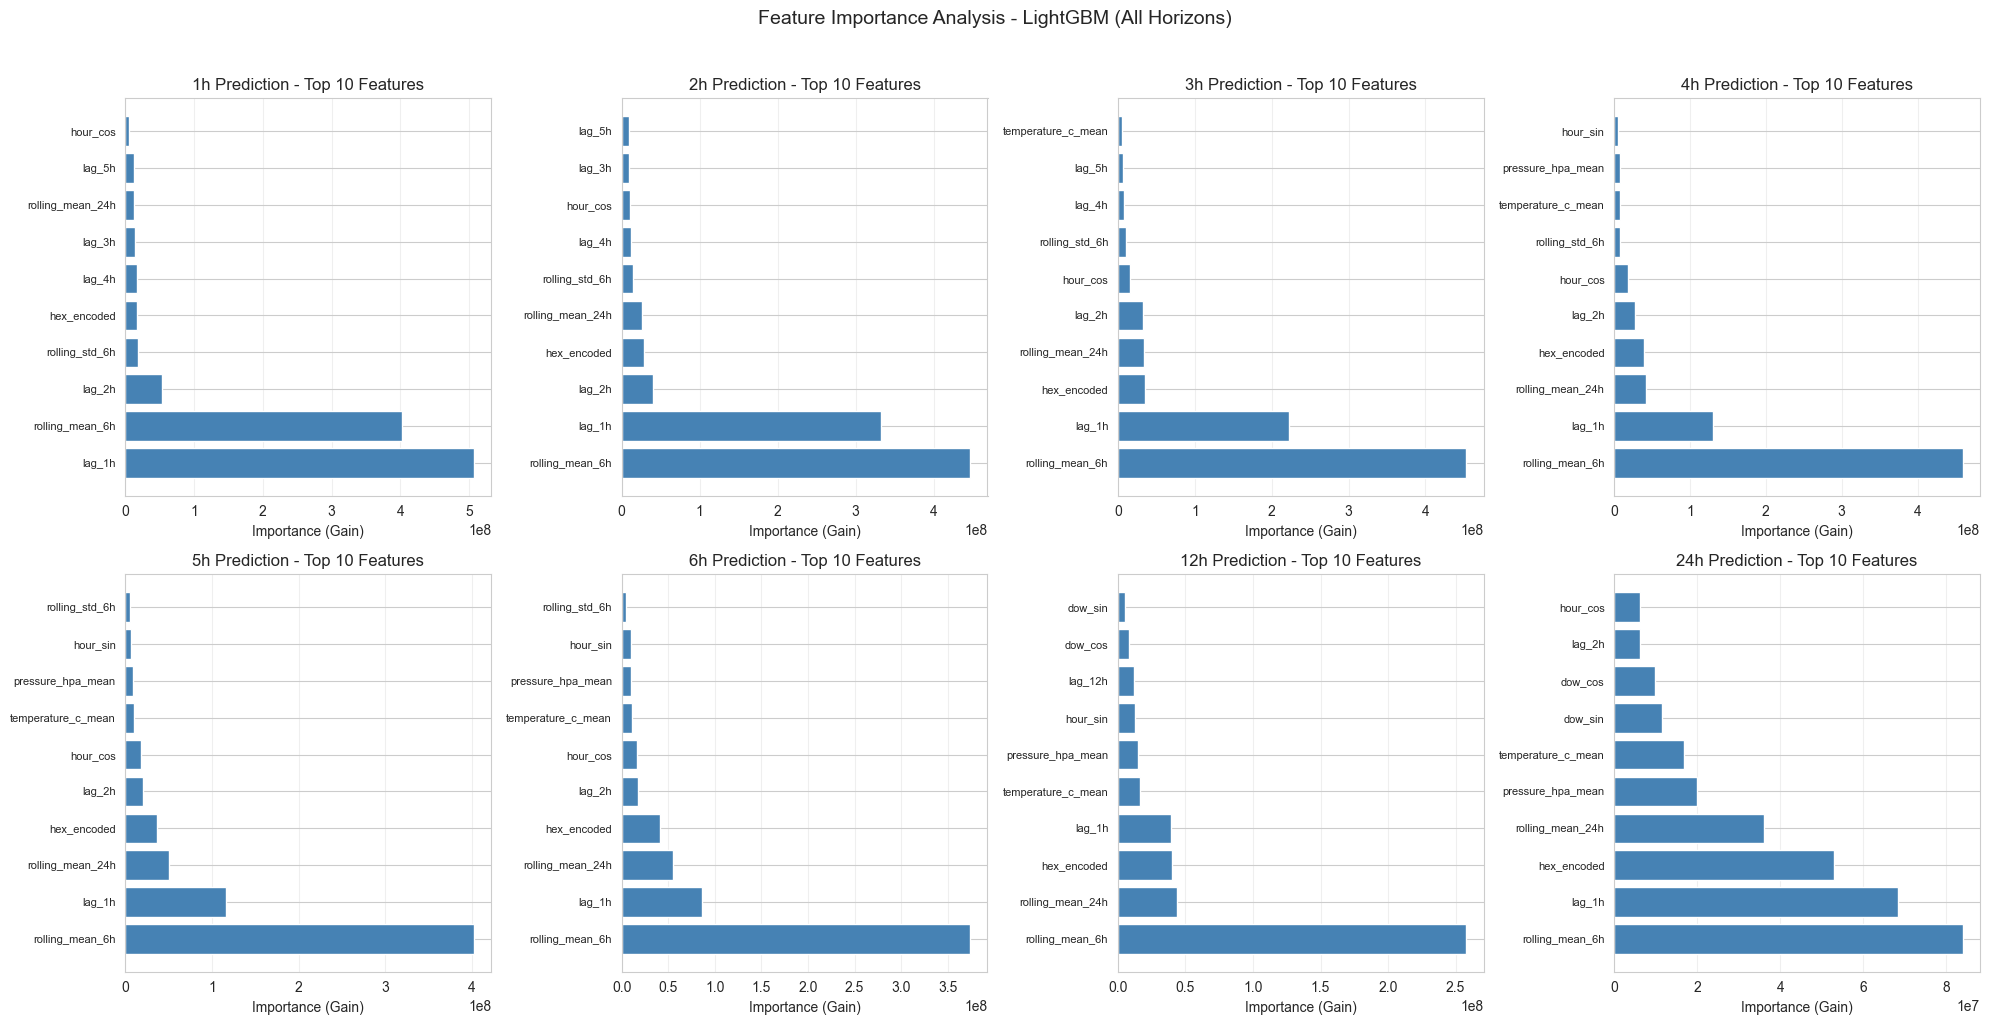

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, horizon in enumerate(horizon_list):
    if 'model' in results[horizon]['LightGBM']:
        model = results[horizon]['LightGBM']['model']
        importance = model.feature_importance(importance_type='gain')
        
        feature_imp = pd.DataFrame({
            'feature': feature_cols,
            'importance': importance
        }).sort_values('importance', ascending=False).head(10)
        
        ax = axes[idx]
        ax.barh(range(len(feature_imp)), feature_imp['importance'].values, color='steelblue')
        ax.set_yticks(range(len(feature_imp)))
        ax.set_yticklabels(feature_imp['feature'].values, fontsize=8)
        ax.set_xlabel('Importance (Gain)')
        ax.set_title(f'{horizon} Prediction - Top 10 Features')
        ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Importance Analysis - LightGBM (All Horizons)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. Error Distribution Analysis

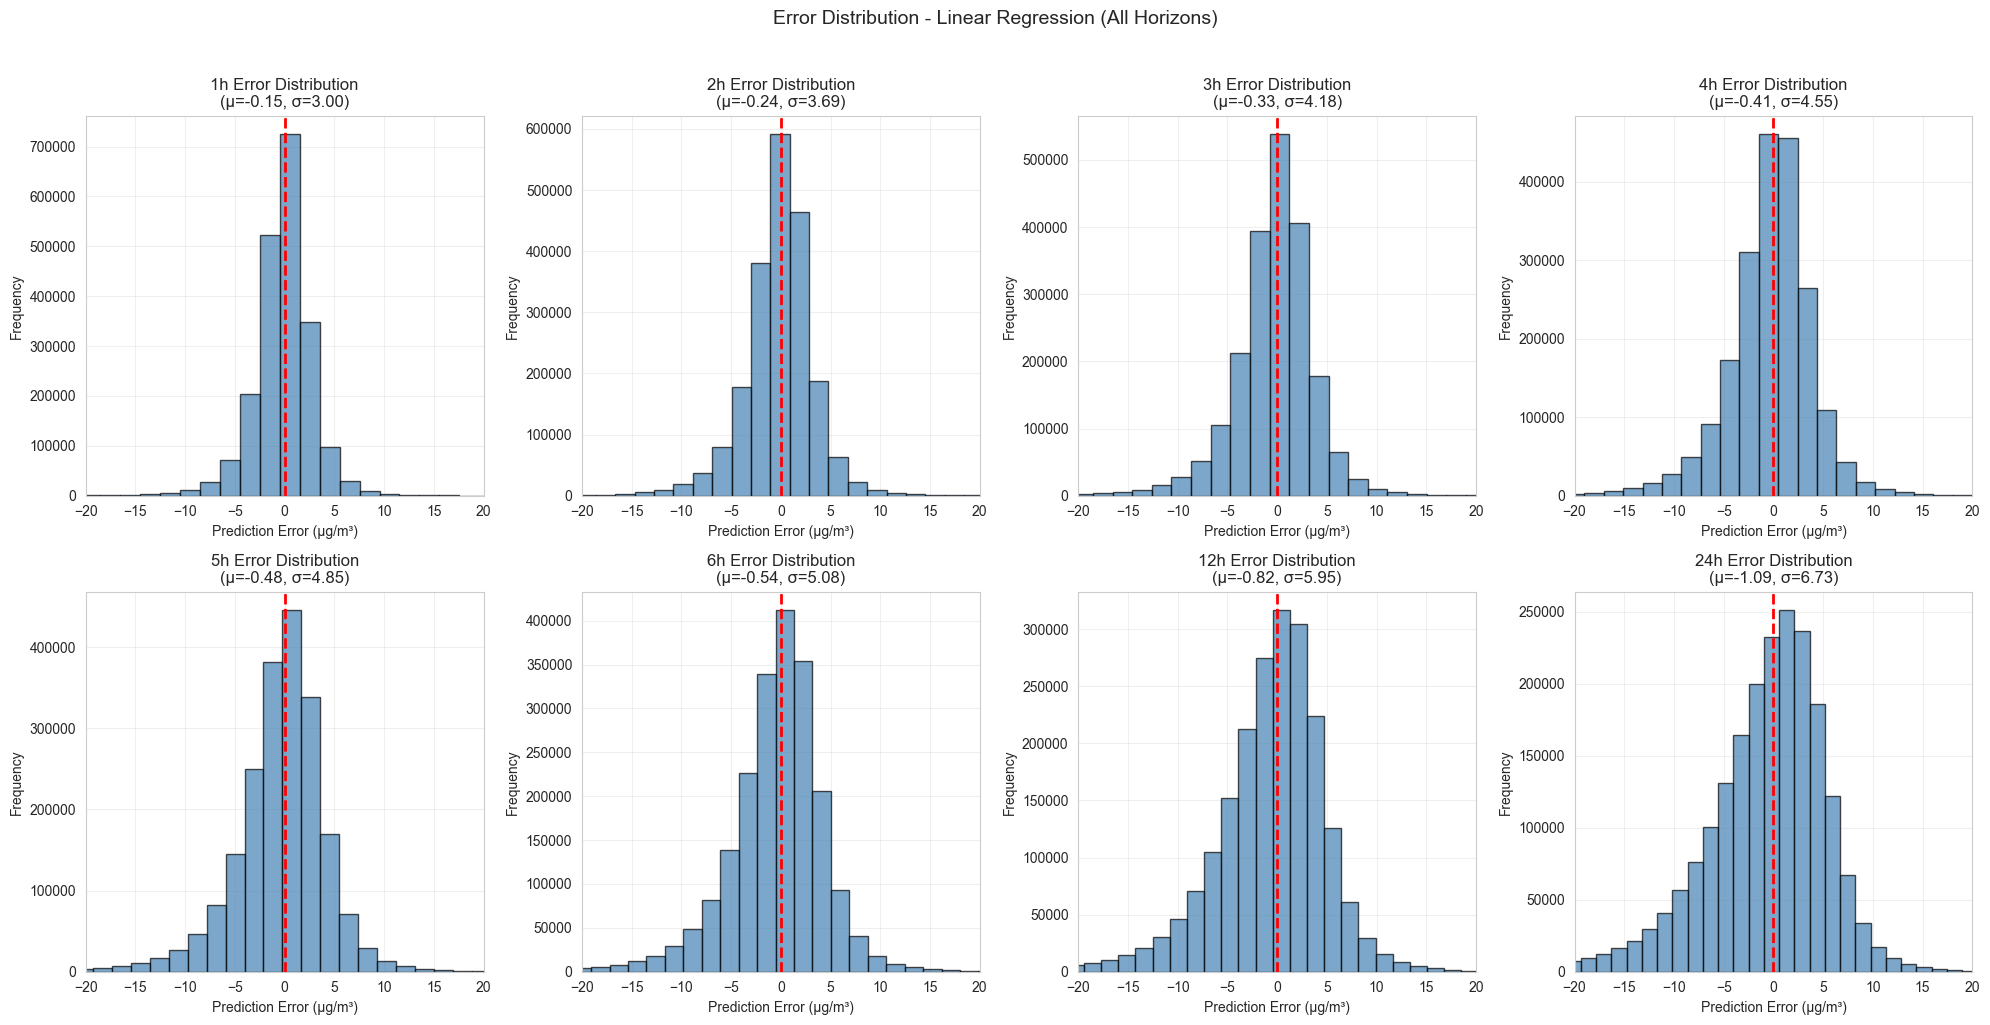

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, horizon in enumerate(horizon_list):
    ax = axes[idx]
    
    y_true = y_test[f'target_{horizon}']
    y_pred = predictions[horizon]['LinearReg']
    errors = y_pred - y_true
    
    ax.hist(errors, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Prediction Error (μg/m³)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{horizon} Error Distribution\n(μ={errors.mean():.2f}, σ={errors.std():.2f})')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-20, 20)

plt.suptitle('Error Distribution - Linear Regression (All Horizons)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 13. Performance Comparison Visualizations

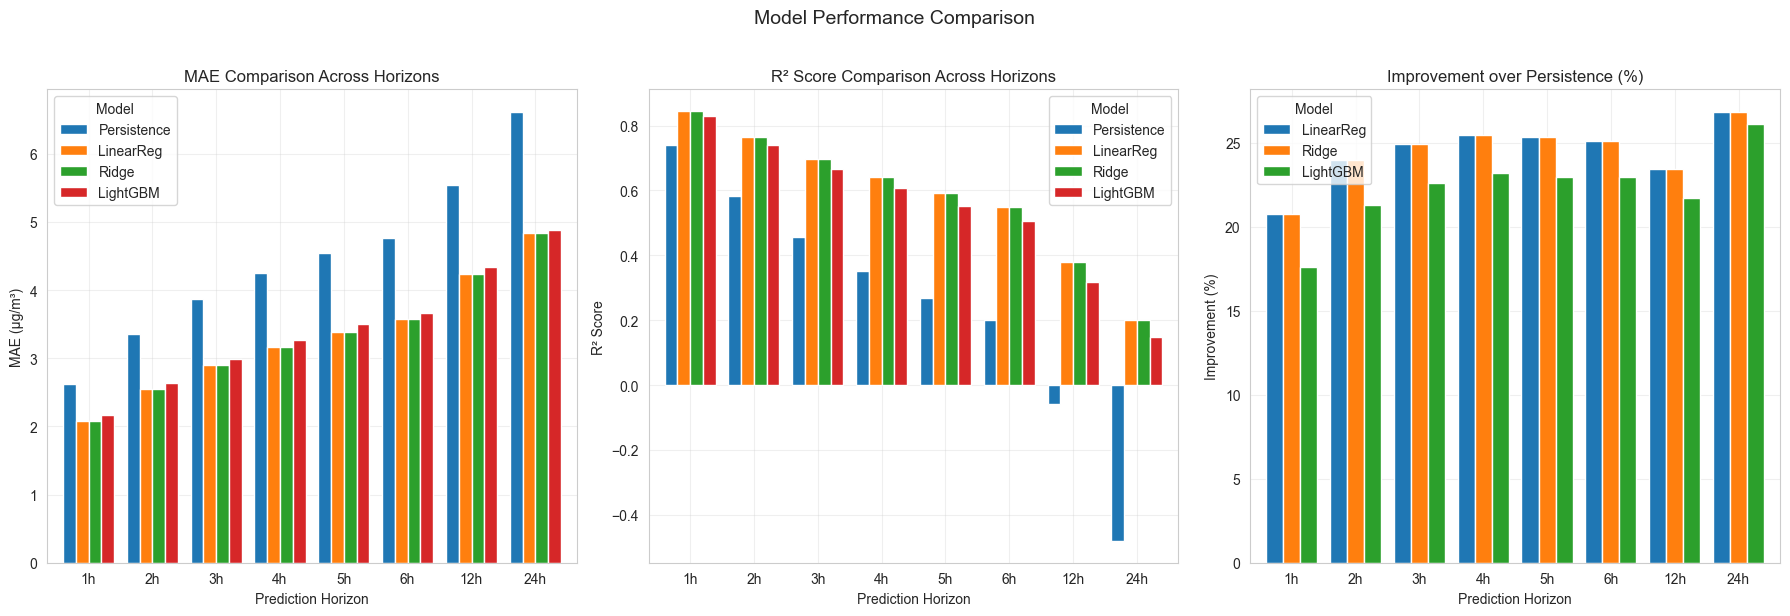

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

mae_table.T.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('MAE Comparison Across Horizons', fontsize=12)
axes[0].set_xlabel('Prediction Horizon')
axes[0].set_ylabel('MAE (μg/m³)')
axes[0].legend(title='Model', loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

r2_table.T.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('R² Score Comparison Across Horizons', fontsize=12)
axes[1].set_xlabel('Prediction Horizon')
axes[1].set_ylabel('R² Score')
axes[1].legend(title='Model', loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

improvement_data = pd.DataFrame()
for horizon in horizon_list:
    persistence_mae = mae_table.loc['Persistence', horizon]
    for model in ['LinearReg', 'Ridge', 'LightGBM']:
        model_mae = mae_table.loc[model, horizon]
        improvement = (persistence_mae - model_mae) / persistence_mae * 100
        improvement_data.loc[model, horizon] = improvement

improvement_data.T.plot(kind='bar', ax=axes[2], width=0.8)
axes[2].set_title('Improvement over Persistence (%)', fontsize=12)
axes[2].set_xlabel('Prediction Horizon')
axes[2].set_ylabel('Improvement (%)')
axes[2].legend(title='Model')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Summary

In [17]:
print("="*70)
print("MODEL TRAINING COMPLETE")
print("="*70)
print(f"\nDataset Summary:")
print(f"  Selected hexagons: {len(high_coverage_hexagons)} (>={COVERAGE_THRESHOLD:.0%} coverage)")
print(f"  Train samples: {len(X_train):,}")
print(f"  Test samples: {len(X_test):,}")
print(f"  Features: {len(feature_cols)}")

print(f"\nBest Model Performance (Typically LinearReg or LightGBM):")
for horizon in horizon_list:
    best_r2 = -999
    best_model = None
    for model in ['LinearReg', 'Ridge', 'LightGBM']:
        if r2_table.loc[model, horizon] > best_r2:
            best_r2 = r2_table.loc[model, horizon]
            best_model = model
    
    mae = mae_table.loc[best_model, horizon]
    print(f"  {horizon:3s}: {best_model:10s} - MAE={mae:.2f} μg/m³, R²={best_r2:.3f}")

print(f"\nKey Success Factors:")
print(f"  ✓ Only high-coverage hexagons (>{COVERAGE_THRESHOLD:.0%})")
print(f"  ✓ Continuous time series maintained")
print(f"  ✓ No lat/lon coordinates used")
print(f"  ✓ Hexagon ID as categorical feature")
print(f"  ✓ All 8 prediction horizons included")
print(f"  ✓ Comprehensive visualization of results")

MODEL TRAINING COMPLETE

Dataset Summary:
  Selected hexagons: 485 (>=90% coverage)
  Train samples: 5,149,984
  Test samples: 2,068,202
  Features: 19

Best Model Performance (Typically LinearReg or LightGBM):
  1h : LinearReg  - MAE=2.08 μg/m³, R²=0.845
  2h : LinearReg  - MAE=2.55 μg/m³, R²=0.765
  3h : LinearReg  - MAE=2.90 μg/m³, R²=0.697
  4h : LinearReg  - MAE=3.17 μg/m³, R²=0.641
  5h : LinearReg  - MAE=3.39 μg/m³, R²=0.592
  6h : LinearReg  - MAE=3.57 μg/m³, R²=0.550
  12h: LinearReg  - MAE=4.24 μg/m³, R²=0.379
  24h: LinearReg  - MAE=4.84 μg/m³, R²=0.201

Key Success Factors:
  ✓ Only high-coverage hexagons (>90%)
  ✓ Continuous time series maintained
  ✓ No lat/lon coordinates used
  ✓ Hexagon ID as categorical feature
  ✓ All 8 prediction horizons included
  ✓ Comprehensive visualization of results
